###Librarys importing

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

###. Loading the Data

In [43]:
data = pd.read_csv('/content/Atlas.csv', encoding='latin1')

###.	Data Inspection

In [44]:
def data_diagnostic(df):
        print("#"*50)
        print(df.info())
        print("#"*50)
        print("The number of total rows  {x: .0f} ".format(x=df.shape[0]))
        print("The number of total variables {x: .0f} ".format(x=df.shape[1]))
        print("The variables names {x:} ".format(x=list(df.columns.values)))

        column_headers =list(df.columns.values)
        qualitative_columns = [col for col in column_headers if df[col].dtype=="object"]
        quantitative_columns = [col for col in column_headers if df[col].dtype in ['int64', 'float64']]

        print("The qualitative variables {x:} ".format(x=qualitative_columns))
        print("The quantitative variables {x:} ".format(x=quantitative_columns))
        print("#"*50)
        print("Total number missing value {x:} ".format(x=df.isnull().sum()))
        print("#"*50)
data_diagnostic(data)

##################################################
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  S

In [45]:
pd.set_option('display.max_columns', None)
data.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [46]:
data.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [47]:
data.describe(include='all')

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
count,9994.000000,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994.000000,9994,9994,9994,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000
unique,NaN,5009,1237,1334,4,793,793,3,1,531,49,NaN,4,1862,3,17,1850,NaN,NaN,NaN,NaN
top,NaN,CA-2017-100111,9/5/2016,12/16/2015,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,California,NaN,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope,NaN,NaN,NaN,NaN
freq,NaN,14,38,35,5968,37,37,5191,9994,915,2001,NaN,3203,19,6026,1523,48,NaN,NaN,NaN,NaN
mean,4997.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,55190.379428,NaN,NaN,NaN,NaN,NaN,229.858001,3.789574,0.156203,28.656896
std,2885.163629,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,32063.693350,NaN,NaN,NaN,NaN,NaN,623.245101,2.225110,0.206452,234.260108
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1040.000000,NaN,NaN,NaN,NaN,NaN,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23223.000000,NaN,NaN,NaN,NaN,NaN,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,56430.500000,NaN,NaN,NaN,NaN,NaN,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,90008.000000,NaN,NaN,NaN,NaN,NaN,209.940000,5.000000,0.200000,29.364000


In [48]:
data["Order Date"] = pd.to_datetime(data["Order Date"])
data["Ship Date"] = pd.to_datetime(data["Ship Date"])

data["Order Month"] = data["Order Date"].dt.month
data["Order Year"] = data["Order Date"].dt.year


In [49]:
min_date = data['Order Date'].min()
max_date = data['Order Date'].max()

print("Dataset starts:", min_date)
print("Dataset ends:", max_date)
print("Years covered:", min_date.year, "to", max_date.year)

Dataset starts: 2014-01-03 00:00:00
Dataset ends: 2017-12-30 00:00:00
Years covered: 2014 to 2017


In [50]:
n_categories = data['Category'].nunique()

print("Number of unique categories:", n_categories)

print(data['Category'].unique())

Number of unique categories: 3
['Furniture' 'Office Supplies' 'Technology']


In [51]:
region_counts = data['Region'].value_counts()

print(region_counts)


print("Top region:", region_counts.idxmax())

Region
West       3203
East       2848
Central    2323
South      1620
Name: count, dtype: int64
Top region: West


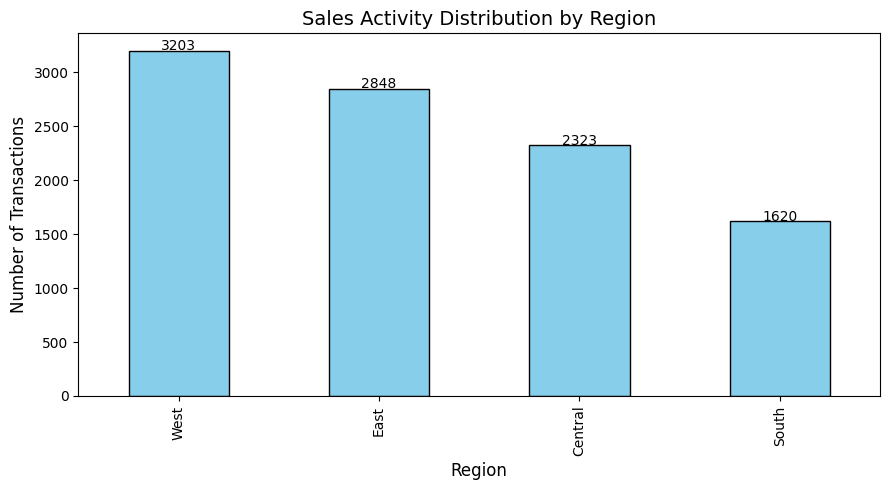

In [52]:
plt.figure(figsize=(9,5))
region_counts.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title("Sales Activity Distribution by Region", fontsize=14)
plt.xlabel("Region", fontsize=12)
plt.ylabel("Number of Transactions", fontsize=12)

for i, v in enumerate(region_counts):
    plt.text(i, v + 5, str(v), ha='center')

plt.tight_layout()
plt.show()

In [53]:
 total_profit=data['Profit'].sum()
print(f"The total profit across the entire dataset is: ${total_profit:.2f}")

The total profit across the entire dataset is: $286397.02


In [54]:
num_customers = data['Customer ID'].nunique()
print(f"There are {num_customers} unique customers in total.")

There are 793 unique customers in total.


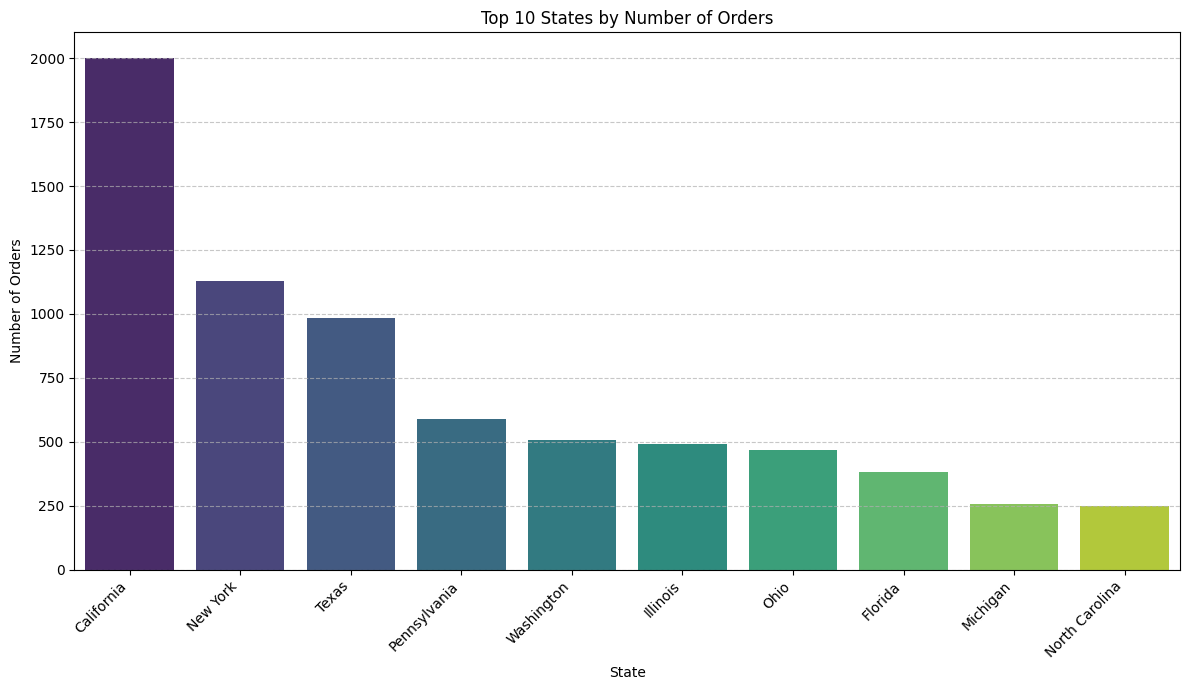

In [55]:
state_order_counts = data['State'].value_counts()
plt.figure(figsize=(12, 7))
sns.barplot(x=state_order_counts.head(10).index, y=state_order_counts.head(10).values, hue=state_order_counts.head(10).index, palette='viridis', legend=False)
plt.title('Top 10 States by Number of Orders')
plt.xlabel('State')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [56]:
order_sales = data.groupby("Order ID")["Sales"].sum()


average_order_value = order_sales.mean()
print("Average sales value per order:", average_order_value)



Average sales value per order: 458.61466566180883


In [57]:
category_summary = data.groupby("Category")[["Sales", "Profit", "Quantity", "Discount"]].sum()


category_summary["Profit Margin (%)"] = (category_summary["Profit"] / category_summary["Sales"]) * 100

print(category_summary)

                       Sales       Profit  Quantity  Discount  \
Category                                                        
Furniture        741999.7953   18451.2728      8028    368.89   
Office Supplies  719047.0320  122490.8008     22906    947.80   
Technology       836154.0330  145454.9481      6939    244.40   

                 Profit Margin (%)  
Category                            
Furniture                 2.486695  
Office Supplies          17.035158  
Technology               17.395712  


In [58]:
category_profit = data.groupby('Category')['Profit'].sum().sort_values(ascending=False)
print("Profit by Product Category:")
print(category_profit)

highest_profit_category = category_profit.index[0]
highest_profit_amount = category_profit.iloc[0]

print(f"\nTo increase profit in the next quarter, I would recommend focusing on the '{highest_profit_category}' category.\nThis category currently generates the highest profit of ${highest_profit_amount:.2f}.\nBy further optimizing strategies within this already high-performing category, there's potential to significantly boost overall profitability.")

Profit by Product Category:
Category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: Profit, dtype: float64

To increase profit in the next quarter, I would recommend focusing on the 'Technology' category.
This category currently generates the highest profit of $145454.95.
By further optimizing strategies within this already high-performing category, there's potential to significantly boost overall profitability.


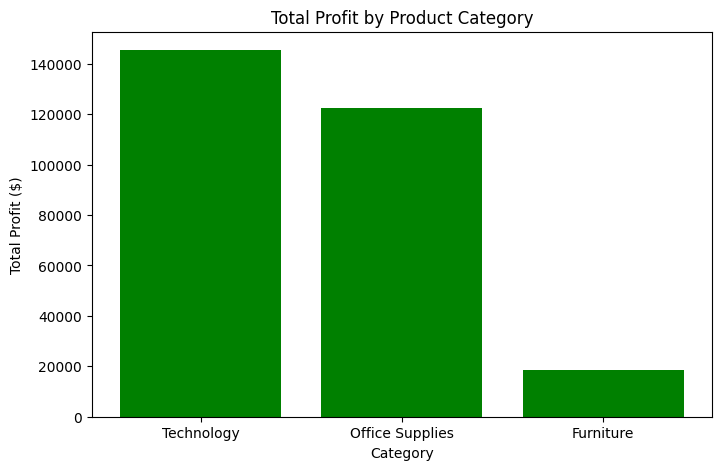

In [59]:
category_summary = category_summary.sort_values("Profit", ascending=False)

plt.figure(figsize=(8,5))
plt.bar(category_summary.index, category_summary["Profit"], color='green')
plt.title("Total Profit by Product Category")
plt.xlabel("Category")
plt.ylabel("Total Profit ($)")
plt.show()

                    Sales       Profit  Quantity  Discount  Profit Margin (%)
Segment                                                                      
Consumer     1.161401e+06  134119.2092     19521    820.91          11.548050
Corporate    7.061464e+05   91979.1340     11608    477.85          13.025506
Home Office  4.296531e+05   60298.6785      6744    262.33          14.034269


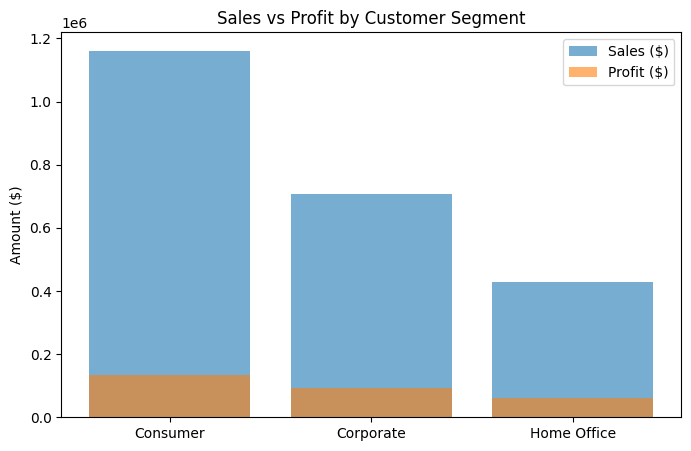

In [60]:
segment_summary = data.groupby("Segment")[["Sales", "Profit", "Quantity", "Discount"]].sum()


segment_summary["Profit Margin (%)"] = (segment_summary["Profit"] / segment_summary["Sales"]) * 100


segment_summary = segment_summary.sort_values("Sales", ascending=False)

print(segment_summary)


plt.figure(figsize=(8,5))
plt.bar(segment_summary.index, segment_summary["Sales"], label="Sales ($)", alpha=0.6)
plt.bar(segment_summary.index, segment_summary["Profit"], label="Profit ($)", alpha=0.6)
plt.title("Sales vs Profit by Customer Segment")
plt.ylabel("Amount ($)")
plt.legend()
plt.show()

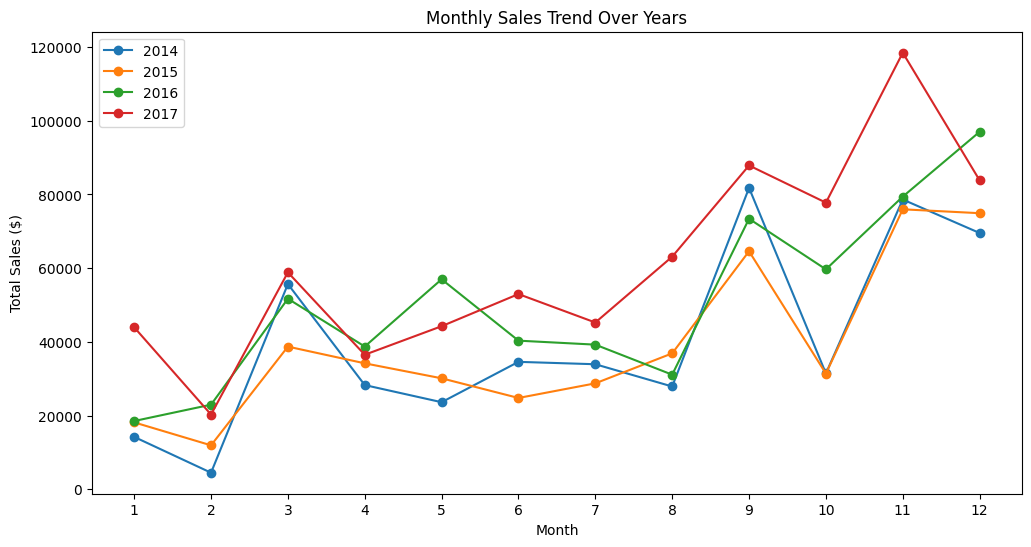

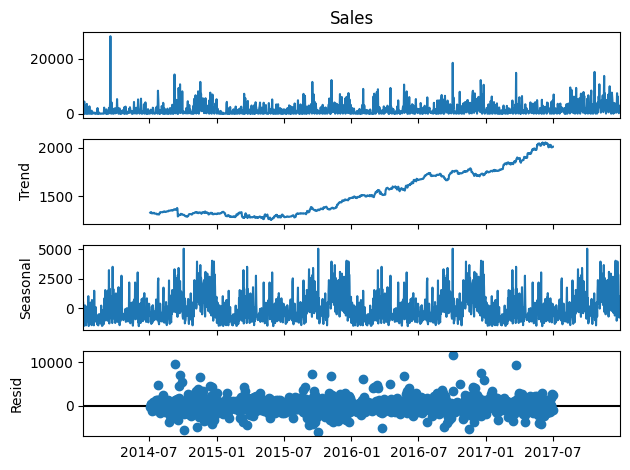

In [61]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Step 1: Convert dates and extract time features
data['Order Date'] = pd.to_datetime(data['Order Date'])
data['Month'] = data['Order Date'].dt.month
data['Year'] = data['Order Date'].dt.year
data['Quarter'] = data['Order Date'].dt.quarter

# Step 2: Aggregate monthly sales
monthly_sales = data.groupby(['Year', 'Month'])['Sales'].sum().reset_index()

# Optional: pivot table for easy plotting by year
monthly_sales_pivot = monthly_sales.pivot(index='Month', columns='Year', values='Sales')

# Step 3: Plot monthly sales trend over years
plt.figure(figsize=(12,6))
for year in monthly_sales['Year'].unique():
    plt.plot(
        monthly_sales[monthly_sales['Year']==year]['Month'],
        monthly_sales[monthly_sales['Year']==year]['Sales'],
        marker='o', label=str(year)
    )
plt.title("Monthly Sales Trend Over Years")
plt.xlabel("Month")
plt.ylabel("Total Sales ($)")
plt.xticks(range(1,13))
plt.legend()
plt.show()

# Step 4: Seasonal decomposition
# Aggregate sales daily (or use monthly sum for coarser view)
daily_sales = data.groupby('Order Date')['Sales'].sum()
daily_sales = daily_sales.asfreq('D').fillna(0)

# Decompose time series (assuming yearly seasonality)
result = seasonal_decompose(daily_sales, model='additive', period=365)
result.plot()
plt.show()

               Sales       Profit  Quantity  Discount  Profit Margin (%)
Region                                                                  
West     725457.8245  108418.4489     12266    350.20          14.944831
East     678781.2400   91522.7800     10618    414.00          13.483399
Central  501239.8908   39706.3625      8780    558.34           7.921629
South    391721.9050   46749.4303      6209    238.55          11.934342


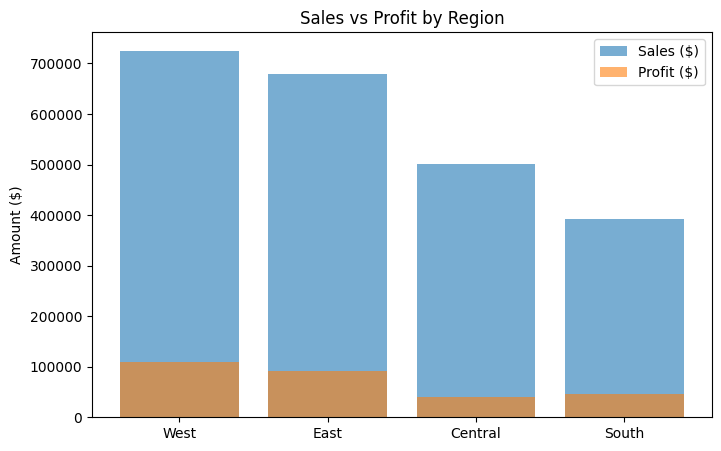

In [62]:
region_summary = data.groupby("Region")[["Sales", "Profit", "Quantity", "Discount"]].sum()


region_summary["Profit Margin (%)"] = (region_summary["Profit"] / region_summary["Sales"]) * 100


region_summary = region_summary.sort_values("Sales", ascending=False)

print(region_summary)

plt.figure(figsize=(8,5))
plt.bar(region_summary.index, region_summary["Sales"], alpha=0.6, label="Sales ($)")
plt.bar(region_summary.index, region_summary["Profit"], alpha=0.6, label="Profit ($)")
plt.title("Sales vs Profit by Region")
plt.ylabel("Amount ($)")
plt.legend()
plt.show()

In [63]:
data['Order Date'] = pd.to_datetime(data['Order Date'])
data['Ship Date'] = pd.to_datetime(data['Ship Date'])
data['Delivery Days'] = (data['Ship Date'] - data['Order Date']).dt.days


shipping_summary = data.groupby('Ship Mode')[['Sales', 'Profit', 'Delivery Days']].mean()
print(shipping_summary)

                     Sales     Profit  Delivery Days
Ship Mode                                           
First Class     228.497024  31.839948       2.182705
Same Day        236.396179  29.266591       0.044199
Second Class    236.089239  29.535545       3.238046
Standard Class  227.583067  27.494770       5.006535
